In [2]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)

In [4]:
df = pd.read_csv("spambase.csv")

print("Dataset Shape :", df.shape)
df.head()

Dataset Shape : (4601, 58)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [5]:
print("First 5 Rows:")
display(df.head())

print("\nDataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

First 5 Rows:


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1



Dataset Shape: (4601, 58)

Column Names:
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_%3B', 'char_freq_%28', 'char_freq_%5B', 'cha

word_freq_make                float64
word_freq_address             float64
word_freq_all                 float64
word_freq_3d                  float64
word_freq_our                 float64
word_freq_over                float64
word_freq_remove              float64
word_freq_internet            float64
word_freq_order               float64
word_freq_mail                float64
word_freq_receive             float64
word_freq_will                float64
word_freq_people              float64
word_freq_report              float64
word_freq_addresses           float64
word_freq_free                float64
word_freq_business            float64
word_freq_email               float64
word_freq_you                 float64
word_freq_credit              float64
word_freq_your                float64
word_freq_font                float64
word_freq_000                 float64
word_freq_money               float64
word_freq_hp                  float64
word_freq_hpl                 float64
word_freq_ge


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_r

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


In [6]:
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
display(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

Missing Values in Each Column:


word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre


Total Missing Values: 0


In [7]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape :", y.shape)

print("\nTarget Class Distribution:")
print(y.value_counts())

Feature Matrix Shape : (4601, 57)
Target Vector Shape : (4601,)

Target Class Distribution:
class
0    2788
1    1813
Name: count, dtype: int64


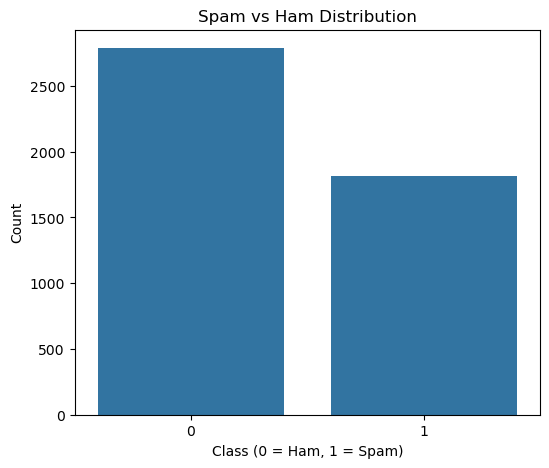

class
0    60.595523
1    39.404477
Name: proportion, dtype: float64


In [8]:
plt.figure(figsize=(6,5))

sns.countplot(x=y)

plt.title("Spam vs Ham Distribution")
plt.xlabel("Class (0 = Ham, 1 = Spam)")
plt.ylabel("Count")

plt.show()

print(y.value_counts(normalize=True)*100)

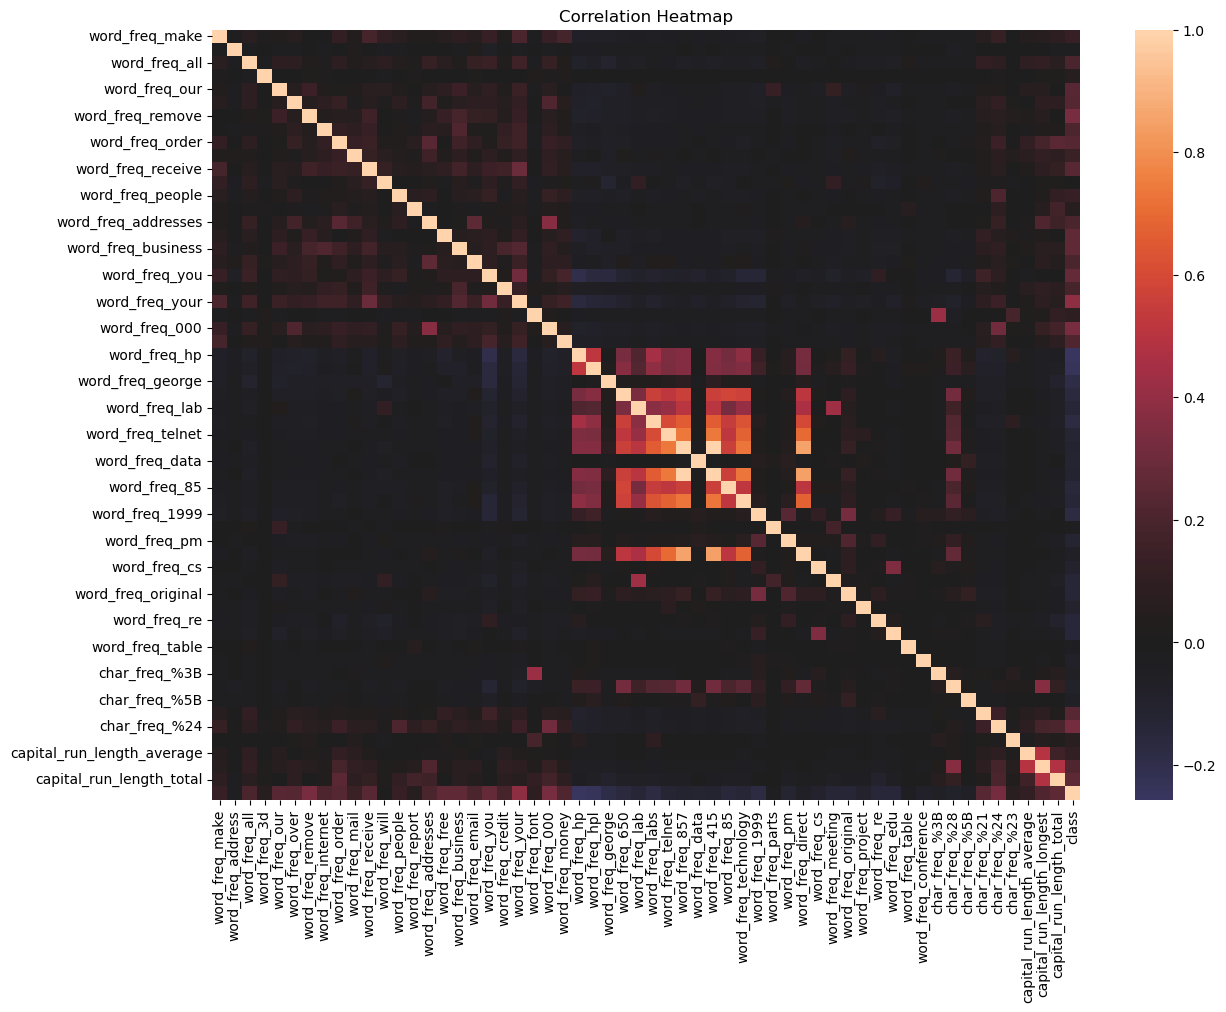

In [11]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(),            
            center=0)

plt.title("Correlation Heatmap")

plt.show()

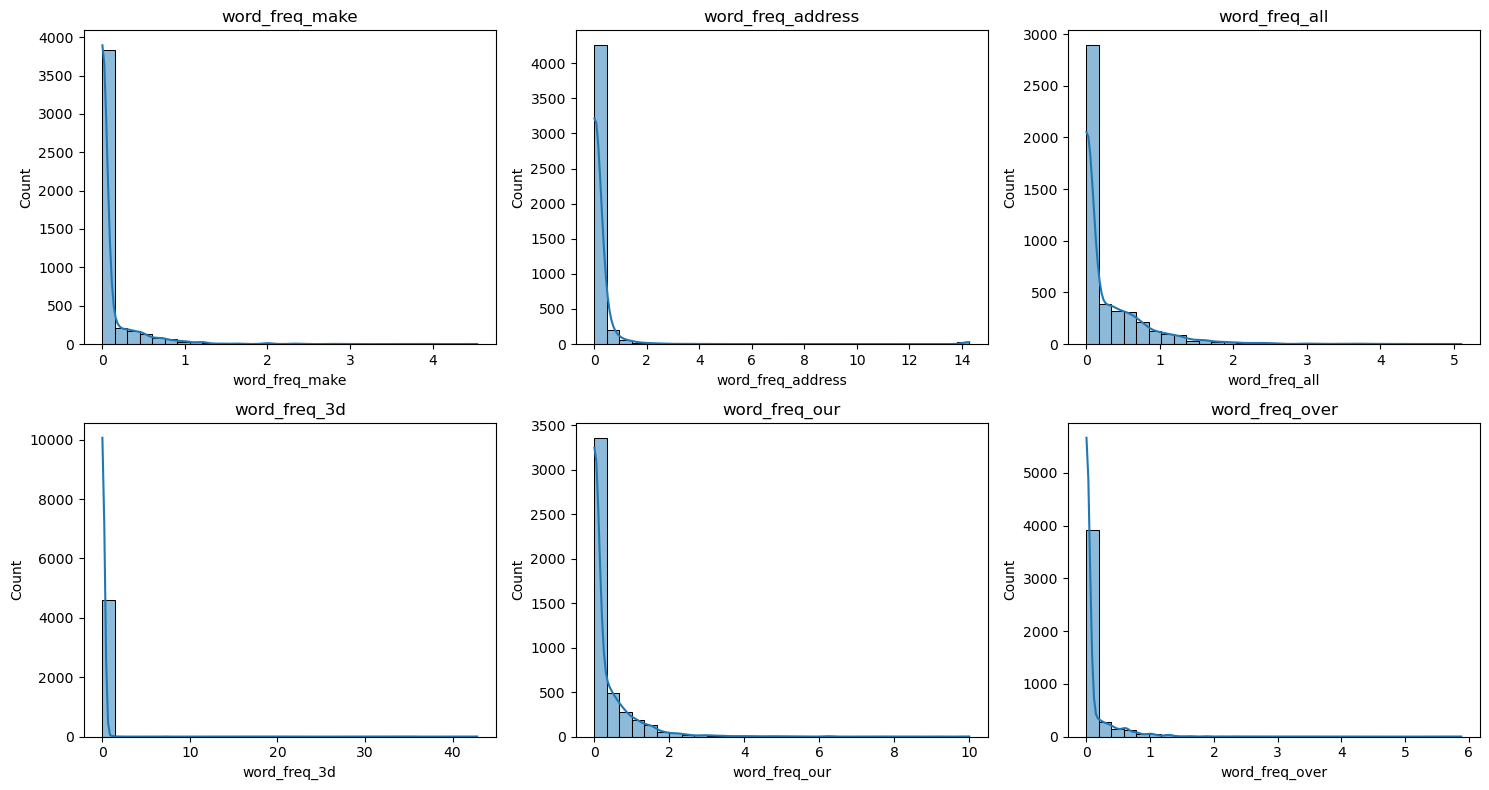

In [12]:
selected_features = X.columns[:6]

fig, axes = plt.subplots(2,3, figsize=(15,8))

for ax, feature in zip(axes.flatten(), selected_features):
    sns.histplot(df[feature], bins=30, kde=True, ax=ax)
    ax.set_title(feature)

plt.tight_layout()

plt.show()

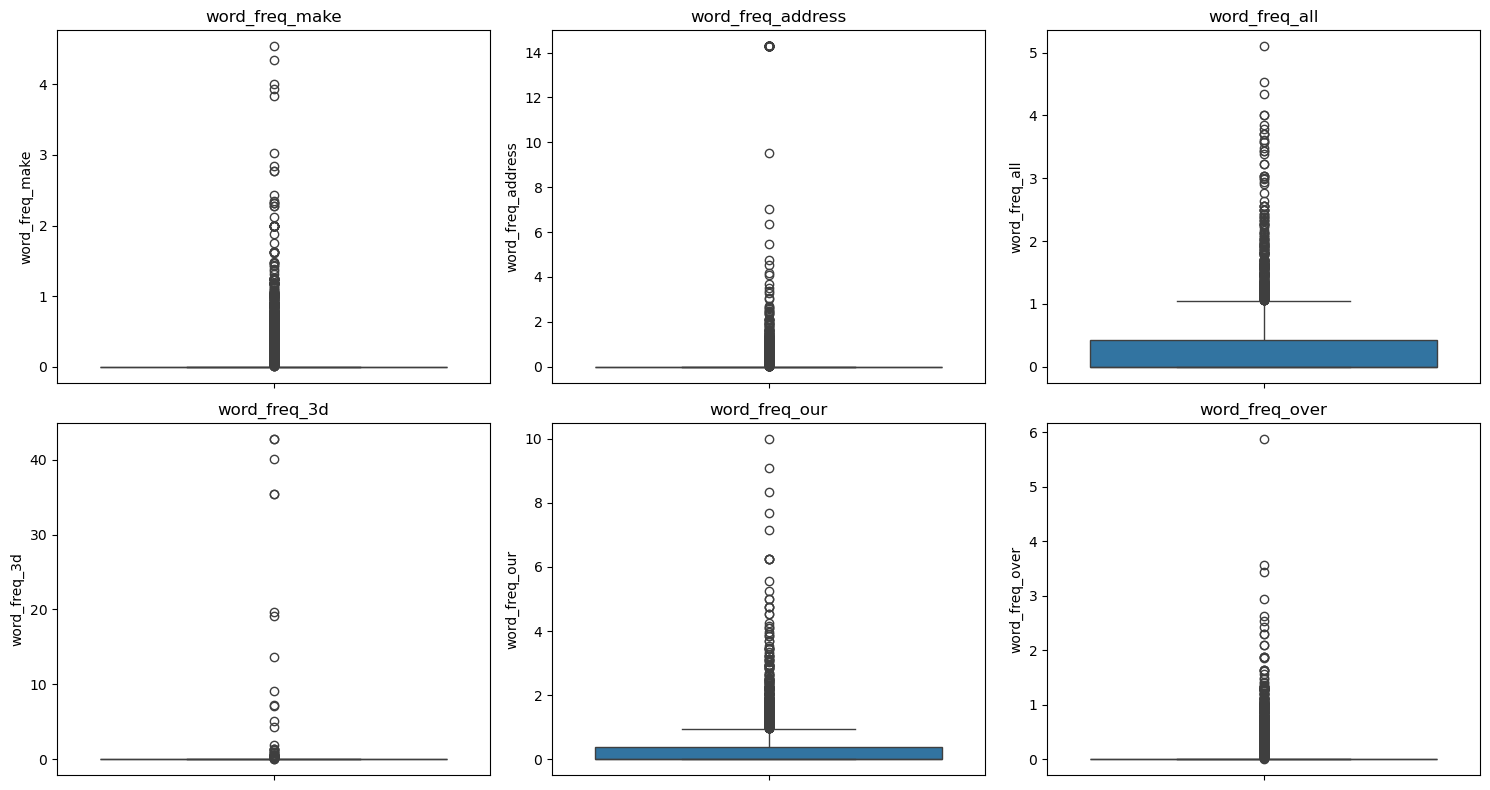

In [13]:
fig, axes = plt.subplots(2,3, figsize=(15,8))

for ax, feature in zip(axes.flatten(), selected_features):
    sns.boxplot(y=df[feature], ax=ax)
    ax.set_title(feature)

plt.tight_layout()

plt.show()

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("\nTraining Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features : (3680, 57)
Testing Features  : (921, 57)

Training Labels : (3680,)
Testing Labels  : (921,)


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data standardized successfully.")
print("Testing data standardized successfully.")

Training data standardized successfully.
Testing data standardized successfully.


In [16]:
start = time.time()

log_reg = LogisticRegression(random_state=42)

log_reg.fit(X_train_scaled, y_train)

training_time = time.time() - start

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 0.0107 seconds


In [17]:
y_pred_lr = log_reg.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

performance = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Training Time (s)"],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        training_time
    ]
})

performance

,Metric,Value
0,Accuracy,0.929425
1,Precision,0.920904
2,Recall,0.898072
3,F1 Score,0.909344
4,Training Time (s),0.010672


In [18]:
print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       0.93      0.95      0.94       558
           1       0.92      0.90      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.93       921
weighted avg       0.93      0.93      0.93       921



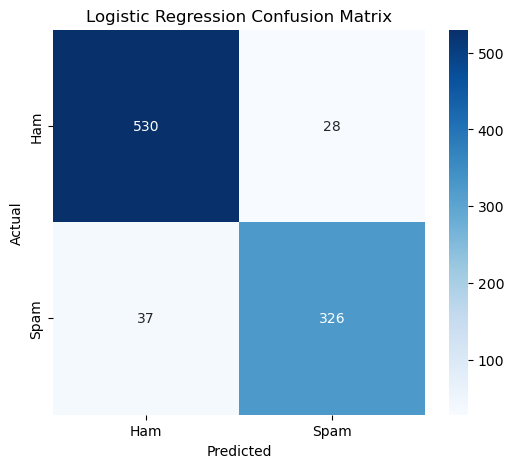

In [19]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham","Spam"],
    yticklabels=["Ham","Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

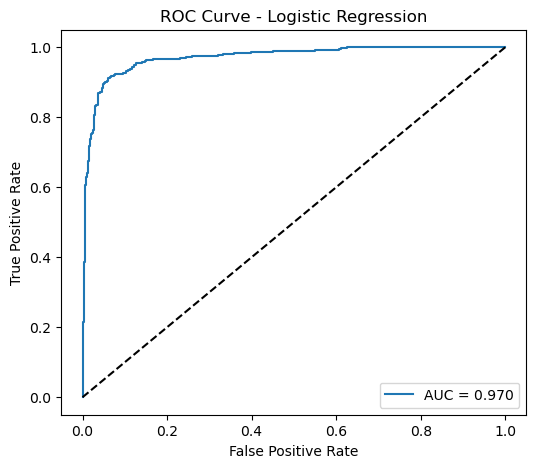

AUC Score : 0.9701956021604116


In [20]:
y_prob = log_reg.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

print("AUC Score :", roc_auc)

In [21]:
param_grid_lr = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}

grid_lr = GridSearchCV(
    estimator=LogisticRegression(max_iter=5000, random_state=42),
    param_grid=param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

start = time.time()

grid_lr.fit(X_train_scaled, y_train)

lr_grid_time = time.time() - start

print("Best Parameters:")
print(grid_lr.best_params_)

print("\nBest Cross Validation Accuracy:")
print(round(grid_lr.best_score_, 4))

print("\nTraining Time:")
print(round(lr_grid_time,4), "seconds")

Best Parameters:
{'C': 1, 'penalty': 'l2', 'solver': 'saga'}

Best Cross Validation Accuracy:
0.9242

Training Time:
23.9927 seconds


In [22]:
best_lr = grid_lr.best_estimator_

y_pred_best_lr = best_lr.predict(X_test_scaled)

accuracy_best = accuracy_score(y_test, y_pred_best_lr)
precision_best = precision_score(y_test, y_pred_best_lr)
recall_best = recall_score(y_test, y_pred_best_lr)
f1_best = f1_score(y_test, y_pred_best_lr)

print("Accuracy :", round(accuracy_best,4))
print("Precision:", round(precision_best,4))
print("Recall   :", round(recall_best,4))
print("F1 Score :", round(f1_best,4))

Accuracy : 0.9305
Precision: 0.9211
Recall   : 0.9008
F1 Score : 0.9109


In [23]:
lr_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time (s)"
    ],
    "Value": [
        round(accuracy_best,4),
        round(precision_best,4),
        round(recall_best,4),
        round(f1_best,4),
        round(lr_grid_time,4)
    ]
})

lr_results

,Metric,Value
0,Accuracy,0.9305
1,Precision,0.9211
2,Recall,0.9008
3,F1 Score,0.9109
4,Training Time (s),23.9927


In [24]:
tuning_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Search Method": ["Grid Search"],
    "Best Parameters": [str(grid_lr.best_params_)],
    "Best CV Accuracy": [round(grid_lr.best_score_,4)]
})

tuning_results

,Model,Search Method,Best Parameters,Best CV Accuracy
0,Logistic Regression,Grid Search,"{'C': 1, 'penalty': 'l2', 'solver': 'saga'}",0.9242


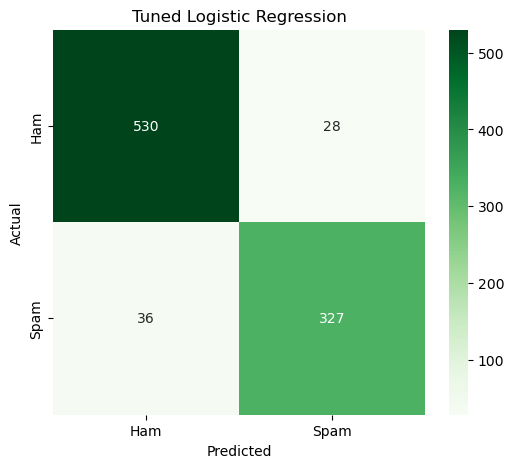

In [25]:
cm = confusion_matrix(y_test, y_pred_best_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Ham','Spam'],
    yticklabels=['Ham','Spam']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned Logistic Regression")

plt.show()

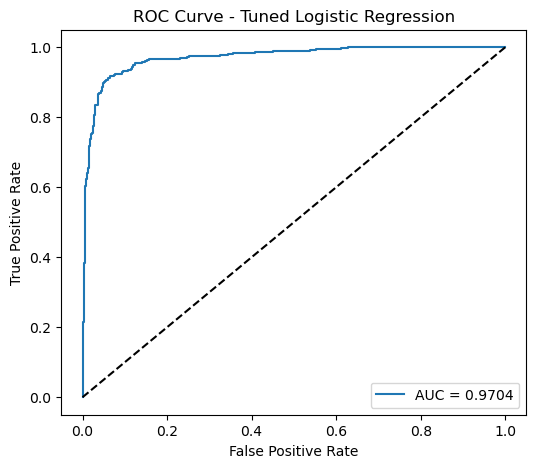

In [26]:
y_prob = best_lr.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Logistic Regression")

plt.legend()

plt.show()

In [31]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

svm_results = []

for kernel in kernels:

    start = time.time()

    svm = SVC(kernel=kernel, random_state=42)

    svm.fit(X_train_scaled, y_train)

    train_time = time.time() - start

    y_pred = svm.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    svm_results.append({
        "Kernel": kernel.capitalize(),
        "Accuracy": round(accuracy,4),
        "F1 Score": round(f1,4),
        "Training Time (s)": round(train_time,4)
    })

svm_results_df = pd.DataFrame(svm_results)

svm_results_df

,Kernel,Accuracy,F1 Score,Training Time (s)
0,Linear,0.9294,0.9093,0.2370
1,Poly,0.7796,0.6220,0.2315
2,Rbf,0.9273,0.9055,0.1295
3,Sigmoid,0.8849,0.8528,0.1340


In [32]:
best_kernel = svm_results_df.loc[
    svm_results_df["Accuracy"].idxmax(),
    "Kernel"
]

print("Best Performing Kernel:", best_kernel)

Best Performing Kernel: Linear


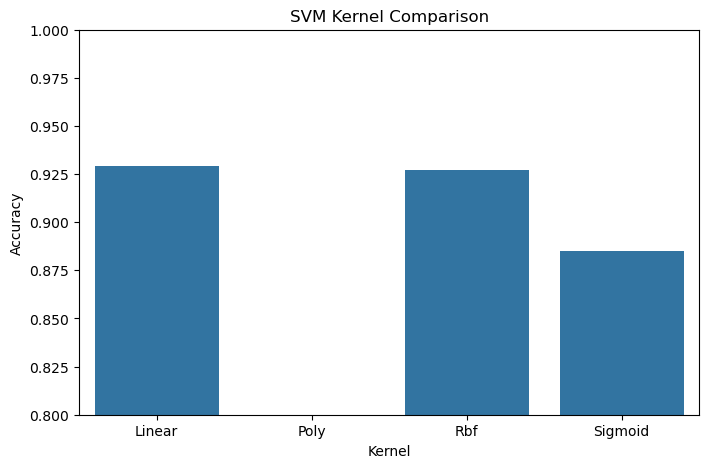

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=svm_results_df,
    x="Kernel",
    y="Accuracy"
)

plt.title("SVM Kernel Comparison")
plt.ylim(0.80,1.00)

plt.show()

In [34]:

best_kernel = best_kernel.lower()

best_svm = SVC(
    kernel=best_kernel,
    probability=True,
    random_state=42
)

start = time.time()

best_svm.fit(X_train_scaled, y_train)

best_svm_time = time.time() - start

y_pred_best_svm = best_svm.predict(X_test_scaled)

accuracy_best_svm = accuracy_score(y_test, y_pred_best_svm)
precision_best_svm = precision_score(y_test, y_pred_best_svm)
recall_best_svm = recall_score(y_test, y_pred_best_svm)
f1_best_svm = f1_score(y_test, y_pred_best_svm)

print("Accuracy :", round(accuracy_best_svm,4))
print("Precision:", round(precision_best_svm,4))
print("Recall   :", round(recall_best_svm,4))
print("F1 Score :", round(f1_best_svm,4))

Accuracy : 0.9294
Precision: 0.9209
Recall   : 0.8981
F1 Score : 0.9093


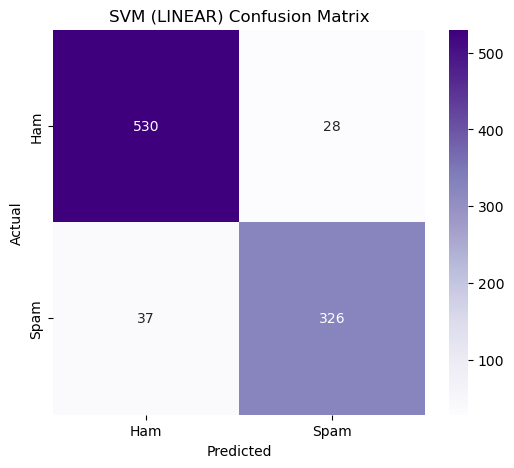

In [35]:
cm = confusion_matrix(y_test, y_pred_best_svm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Ham','Spam'],
    yticklabels=['Ham','Spam']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"SVM ({best_kernel.upper()}) Confusion Matrix")

plt.show()

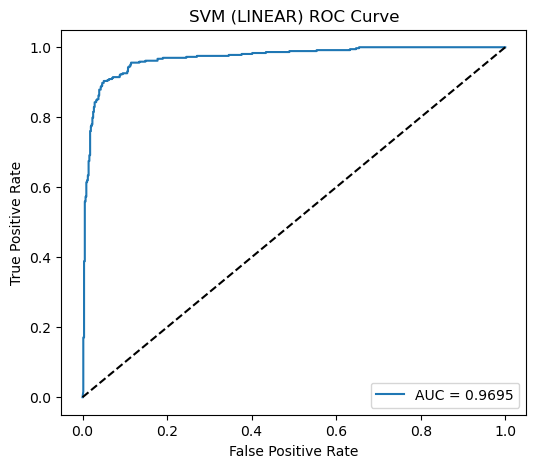

In [36]:
y_prob = best_svm.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(f"SVM ({best_kernel.upper()}) ROC Curve")

plt.legend()

plt.show()

In [37]:
param_grid_svm = [
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10, 100]
    },
    {
        'kernel': ['rbf', 'sigmoid'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto']
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto'],
        'degree': [2, 3, 4]
    }
]

grid_svm = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

start = time.time()

grid_svm.fit(X_train_scaled, y_train)

svm_grid_time = time.time() - start

print("Best Parameters:")
print(grid_svm.best_params_)

print("\nBest Cross Validation Accuracy:")
print(round(grid_svm.best_score_,4))

print("\nTraining Time:")
print(round(svm_grid_time,4),"seconds")

Best Parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Best Cross Validation Accuracy:
0.9332

Training Time:
15.5717 seconds


In [38]:
best_svm = grid_svm.best_estimator_

start = time.time()

best_svm.fit(X_train_scaled, y_train)

svm_train_time = time.time() - start

y_pred_svm = best_svm.predict(X_test_scaled)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("Accuracy :", round(accuracy_svm,4))
print("Precision:", round(precision_svm,4))
print("Recall   :", round(recall_svm,4))
print("F1 Score :", round(f1_svm,4))

Accuracy : 0.9207
Precision: 0.9143
Recall   : 0.8815
F1 Score : 0.8976


In [39]:
tuning_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM"
    ],
    "Search Method": [
        "Grid Search",
        "Grid Search"
    ],
    "Best Parameters": [
        str(grid_lr.best_params_),
        str(grid_svm.best_params_)
    ],
    "Best CV Accuracy": [
        round(grid_lr.best_score_,4),
        round(grid_svm.best_score_,4)
    ]
})

tuning_results

,Model,Search Method,Best Parameters,Best CV Accuracy
0,Logistic Regression,Grid Search,"{'C': 1, 'penalty': 'l2', 'solver': 'saga'}",0.9242
1,SVM,Grid Search,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.9332


In [40]:
svm_performance = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time (s)"
    ],
    "Value":[
        round(accuracy_svm,4),
        round(precision_svm,4),
        round(recall_svm,4),
        round(f1_svm,4),
        round(svm_train_time,4)
    ]
})

svm_performance

,Metric,Value
0,Accuracy,0.9207
1,Precision,0.9143
2,Recall,0.8815
3,F1 Score,0.8976
4,Training Time (s),0.1130


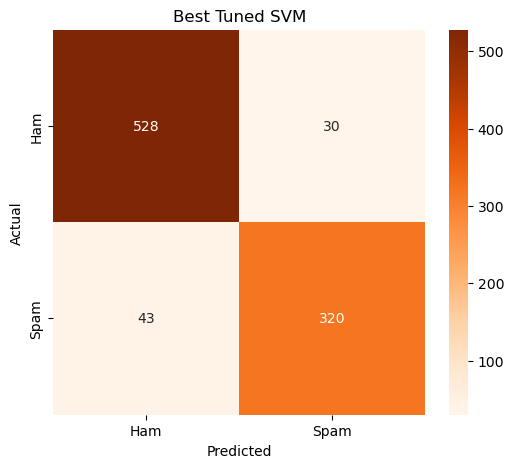

In [41]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Ham','Spam'],
    yticklabels=['Ham','Spam']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Best Tuned SVM")

plt.show()

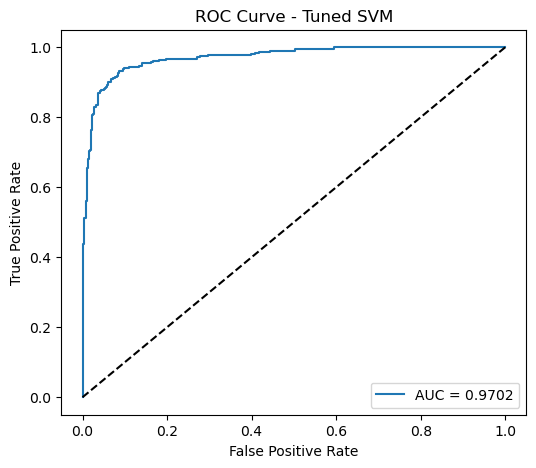

In [42]:
best_svm_probability = SVC(
    **grid_svm.best_params_,
    probability=True,
    random_state=42
)

best_svm_probability.fit(X_train_scaled, y_train)

y_prob = best_svm_probability.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Tuned SVM")

plt.legend()

plt.show()

In [45]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_cv = cross_validate(
    best_lr,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='accuracy'
)

svm_cv = cross_validate(
    best_svm,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='accuracy'
)

cv_results = pd.DataFrame({
    "Fold":[
        "Fold 1",
        "Fold 2",
        "Fold 3",
        "Fold 4",
        "Fold 5",
        "Average"
    ],
    "Logistic Regression":[
        *np.round(lr_cv["test_score"],4),
        round(np.mean(lr_cv["test_score"]),4)
    ],
    "SVM":[
        *np.round(svm_cv["test_score"],4),
        round(np.mean(svm_cv["test_score"]),4)
    ]
})

cv_results

,Fold,Logistic Regression,SVM
0,Fold 1,0.9375,0.9443
1,Fold 2,0.9253,0.9416
2,Fold 3,0.9307,0.9348
3,Fold 4,0.9076,0.9307
4,Fold 5,0.9171,0.9266
5,Average,0.9236,0.9356


In [46]:
comparison = pd.DataFrame({
    "Criterion":[
        "Accuracy",
        "Model Complexity",
        "Training Time",
        "Interpretability"
    ],
    "Logistic Regression":[
        round(accuracy_best,4),
        "Low",
        "Low",
        "High"
    ],
    "SVM":[
        round(accuracy_svm,4),
        "High",
        "High",
        "Low"
    ]
})

comparison

,Criterion,Logistic Regression,SVM
0,Accuracy,0.9305,0.9207
1,Model Complexity,Low,High
2,Training Time,Low,High
3,Interpretability,High,Low


In [47]:
print("=" * 60)
print("Hyperparameter Tuning Results")
print("=" * 60)
display(tuning_results)

print("=" * 60)
print("Logistic Regression Performance")
print("=" * 60)
display(lr_results)

print("=" * 60)
print("SVM Kernel-wise Performance")
print("=" * 60)
display(svm_results_df)

print("=" * 60)
print("5-Fold Cross Validation")
print("=" * 60)
display(cv_results)

print("=" * 60)
print("Comparative Analysis")
print("=" * 60)
display(comparison)


Hyperparameter Tuning Results


,Model,Search Method,Best Parameters,Best CV Accuracy
0,Logistic Regression,Grid Search,"{'C': 1, 'penalty': 'l2', 'solver': 'saga'}",0.9242
1,SVM,Grid Search,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.9332


Logistic Regression Performance


,Metric,Value
0,Accuracy,0.9305
1,Precision,0.9211
2,Recall,0.9008
3,F1 Score,0.9109
4,Training Time (s),23.9927


SVM Kernel-wise Performance


,Kernel,Accuracy,F1 Score,Training Time (s)
0,Linear,0.9294,0.9093,0.2370
1,Poly,0.7796,0.6220,0.2315
2,Rbf,0.9273,0.9055,0.1295
3,Sigmoid,0.8849,0.8528,0.1340


5-Fold Cross Validation


,Fold,Logistic Regression,SVM
0,Fold 1,0.9375,0.9443
1,Fold 2,0.9253,0.9416
2,Fold 3,0.9307,0.9348
3,Fold 4,0.9076,0.9307
4,Fold 5,0.9171,0.9266
5,Average,0.9236,0.9356


Comparative Analysis


,Criterion,Logistic Regression,SVM
0,Accuracy,0.9305,0.9207
1,Model Complexity,Low,High
2,Training Time,Low,High
3,Interpretability,High,Low
